# Ex No 8 - Design a program for Object Detection using YOLO 


In [1]:
import sys
!{sys.executable} -m pip install torch torchvision torchaudio -y


[optparse.groups]Usage:[/]   
  C:\Users\91950\AppData\Local\Programs\Python\Python310\python.exe -m pip install \[options] <requirement specifier> \[package-index-options] ...
  C:\Users\91950\AppData\Local\Programs\Python\Python310\python.exe -m pip install \[options] -r <requirements file> \[package-index-options] ...
  C:\Users\91950\AppData\Local\Programs\Python\Python310\python.exe -m pip install \[options] [-e] <vcs project url> ...
  C:\Users\91950\AppData\Local\Programs\Python\Python310\python.exe -m pip install \[options] [-e] <local project path> ...
  C:\Users\91950\AppData\Local\Programs\Python\Python310\python.exe -m pip install \[options] <archive url/path> ...

no such option: -y


In [2]:
import sys
!{sys.executable} -m pip install ultralytics



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



   ---------------------------------------- 0.0/1.2 MB ? eta -:--:--
   ----------------- ---------------------- 0.5/1.2 MB 4.2 MB/s eta 0:00:01
   ---------------------------------------- 1.2/1.2 MB 3.5 MB/s  0:00:00
   ---------------------------------------- 0.0/823.9 kB ? eta -:--:--
   ------------ --------------------------- 262.1/823.9 kB ? eta -:--:--
   ---------------------------------------- 823.9/823.9 kB 3.6 MB/s  0:00:00
   ---------------------------------------- 0.0/47.0 MB ? eta -:--:--
    --------------------------------------- 0.8/47.0 MB 5.6 MB/s eta 0:00:09
   - -------------------------------------- 1.3/47.0 MB 3.4 MB/s eta 0:00:14
   -- ------------------------------------- 2.6/47.0 MB 4.4 MB/s eta 0:00:11
   ---- ----------------------------------- 4.7/47.0 MB 5.9 MB/s eta 0:00:08
   ----- ---------------------------------- 6.6/47.0 MB 6.5 MB/s eta 0:00:07
   -------- ------------------------------- 10.2/47.0 MB 8.4 MB/s eta 0:00:05
   ---------- -------------

In [3]:
!pip install ultralytics


[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
import torch
print(torch.__version__)

2.10.0+cpu


In [5]:
from ultralytics import YOLO
print("YOLO installed successfully")

Creating new Ultralytics Settings v0.0.6 file  
View Ultralytics Settings with 'yolo settings' or at 'C:\Users\91950\AppData\Roaming\Ultralytics\settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
YOLO installed successfully



image 1/1 C:\Users\91950\Downloads\bus.jpg: 640x480 4 persons, 1 bus, 1 stop sign, 192.1ms
Speed: 9.8ms preprocess, 192.1ms inference, 3.4ms postprocess per image at shape (1, 3, 640, 480)


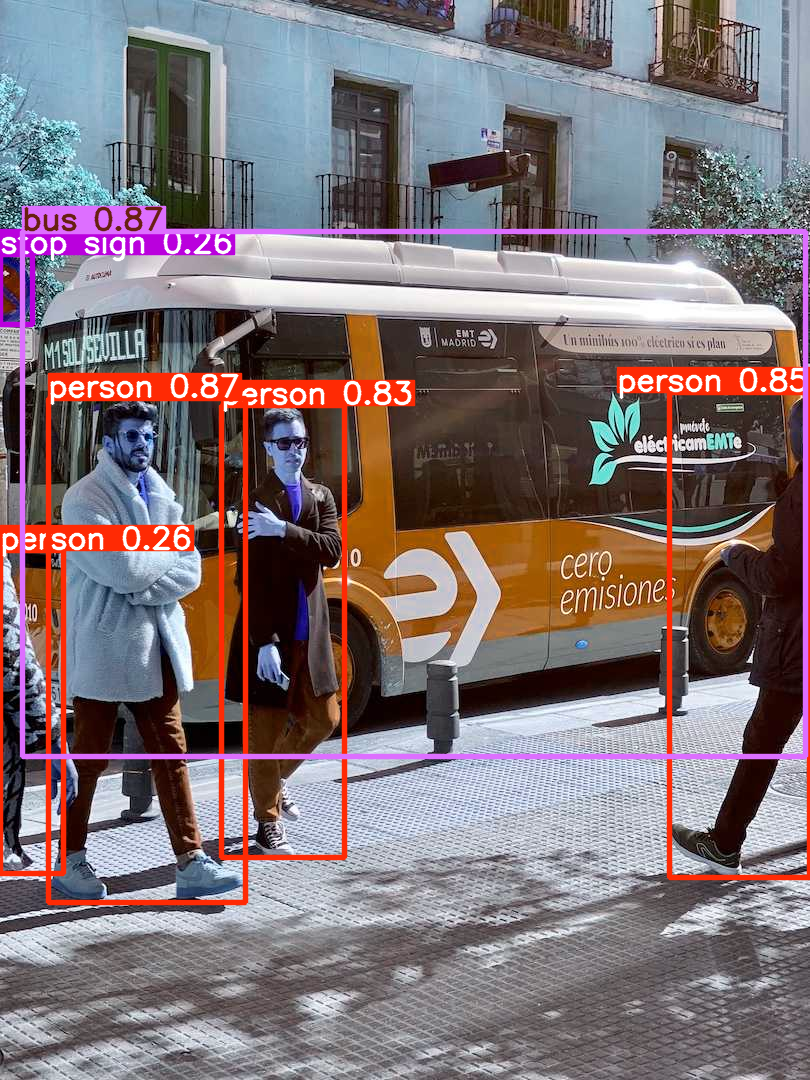

In [7]:
from ultralytics import YOLO
from IPython.display import display
from PIL import Image

model = YOLO("yolov8n.pt")
results = model(r"C:\Users\91950\Downloads\bus.jpg")

img = results[0].plot()
display(Image.fromarray(img))


image 1/1 C:\Users\91950\Downloads\test.png: 224x640 13 persons, 1 bicycle, 2 cars, 1 truck, 1 dog, 1 backpack, 174.2ms
Speed: 3.8ms preprocess, 174.2ms inference, 10.6ms postprocess per image at shape (1, 3, 224, 640)


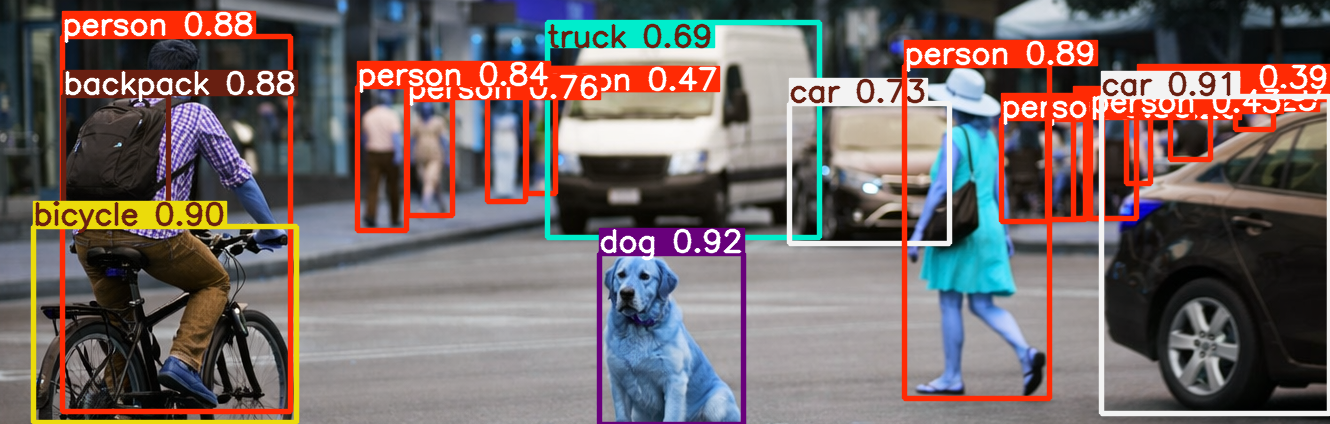

In [8]:
from ultralytics import YOLO
model = YOLO("yolov8n.pt")
results = model(r"C:\Users\91950\Downloads\test.png")

img = results[0].plot()
display(Image.fromarray(img))

In [2]:
import cv2
import random
import os
from ultralytics import YOLO
from IPython.display import Video

# Change to Downloads folder
os.chdir(r"C:\Users\91950\Downloads")

# Load model
model = YOLO("yolov8s.pt")

# Use your saved video file
video_path = r"C:\Users\91950\Downloads\t1.mp4"
cap = cv2.VideoCapture(video_path)

# Get video properties
fps = int(cap.get(cv2.CAP_PROP_FPS))
w = int(cap.get(cv2.CAP_PROP_FRAME_WIDTH))
h = int(cap.get(cv2.CAP_PROP_FRAME_HEIGHT))

# Video writer
out = cv2.VideoWriter(
    "output.mp4",
    cv2.VideoWriter_fourcc(*'mp4v'),
    fps,
    (w, h)
)

# Color function
def get_color(cls_id):
    random.seed(cls_id)
    return tuple(random.randint(0, 255) for _ in range(3))

# LIMIT: Process only first 100 frames
MAX_FRAMES = 100
frame_count = 0

while True:
    ret, frame = cap.read()

    if not ret:
        break

    if frame_count >= MAX_FRAMES:
        print(f"\nReached limit of {MAX_FRAMES} frames. Stopping...")
        break

    # Detect objects
    results = model.track(frame, stream=True, verbose=False)

    for result in results:
        for box in result.boxes:

            if box.conf[0] > 0.4:

                x1, y1, x2, y2 = map(int, box.xyxy[0])
                cls = int(box.cls[0])
                conf = float(box.conf[0])
                track_id = int(box.id[0]) if box.id is not None else 0

                # Draw bounding box
                color = get_color(cls)
                cv2.rectangle(frame, (x1, y1), (x2, y2), color, 2)

                # Draw label
                label = f"{result.names[cls]} ID:{track_id} {conf:.2f}"

                cv2.putText(
                    frame,
                    label,
                    (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.6,
                    color,
                    2
                )

    out.write(frame)
    frame_count += 1

    if frame_count % 10 == 0:
        print(f"Processed {frame_count}/{MAX_FRAMES} frames...")

cap.release()
out.release()

print("Done! Output saved to: C:\\Users\\91950\\Downloads\\output.mp4")

requirements: Ultralytics requirement ['lap>=0.5.12'] not found, attempting AutoUpdate...
   ---------------------------------------- 0.0/1.5 MB ? eta -:--:--
   ---------------------------------------- 1.5/1.5 MB 8.6 MB/s  0:00:00

[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip

requirements: AutoUpdate success  23.7s
WARNING requirements: Restart runtime or rerun command for updates to take effect

Processed 10/100 frames...
Processed 20/100 frames...
Processed 30/100 frames...
Processed 40/100 frames...
Processed 50/100 frames...
Processed 60/100 frames...
Processed 70/100 frames...
Processed 80/100 frames...
Processed 90/100 frames...
Processed 100/100 frames...

Reached limit of 100 frames. Stopping...
Done! Output saved to: C:\Users\91950\Downloads\output.mp4


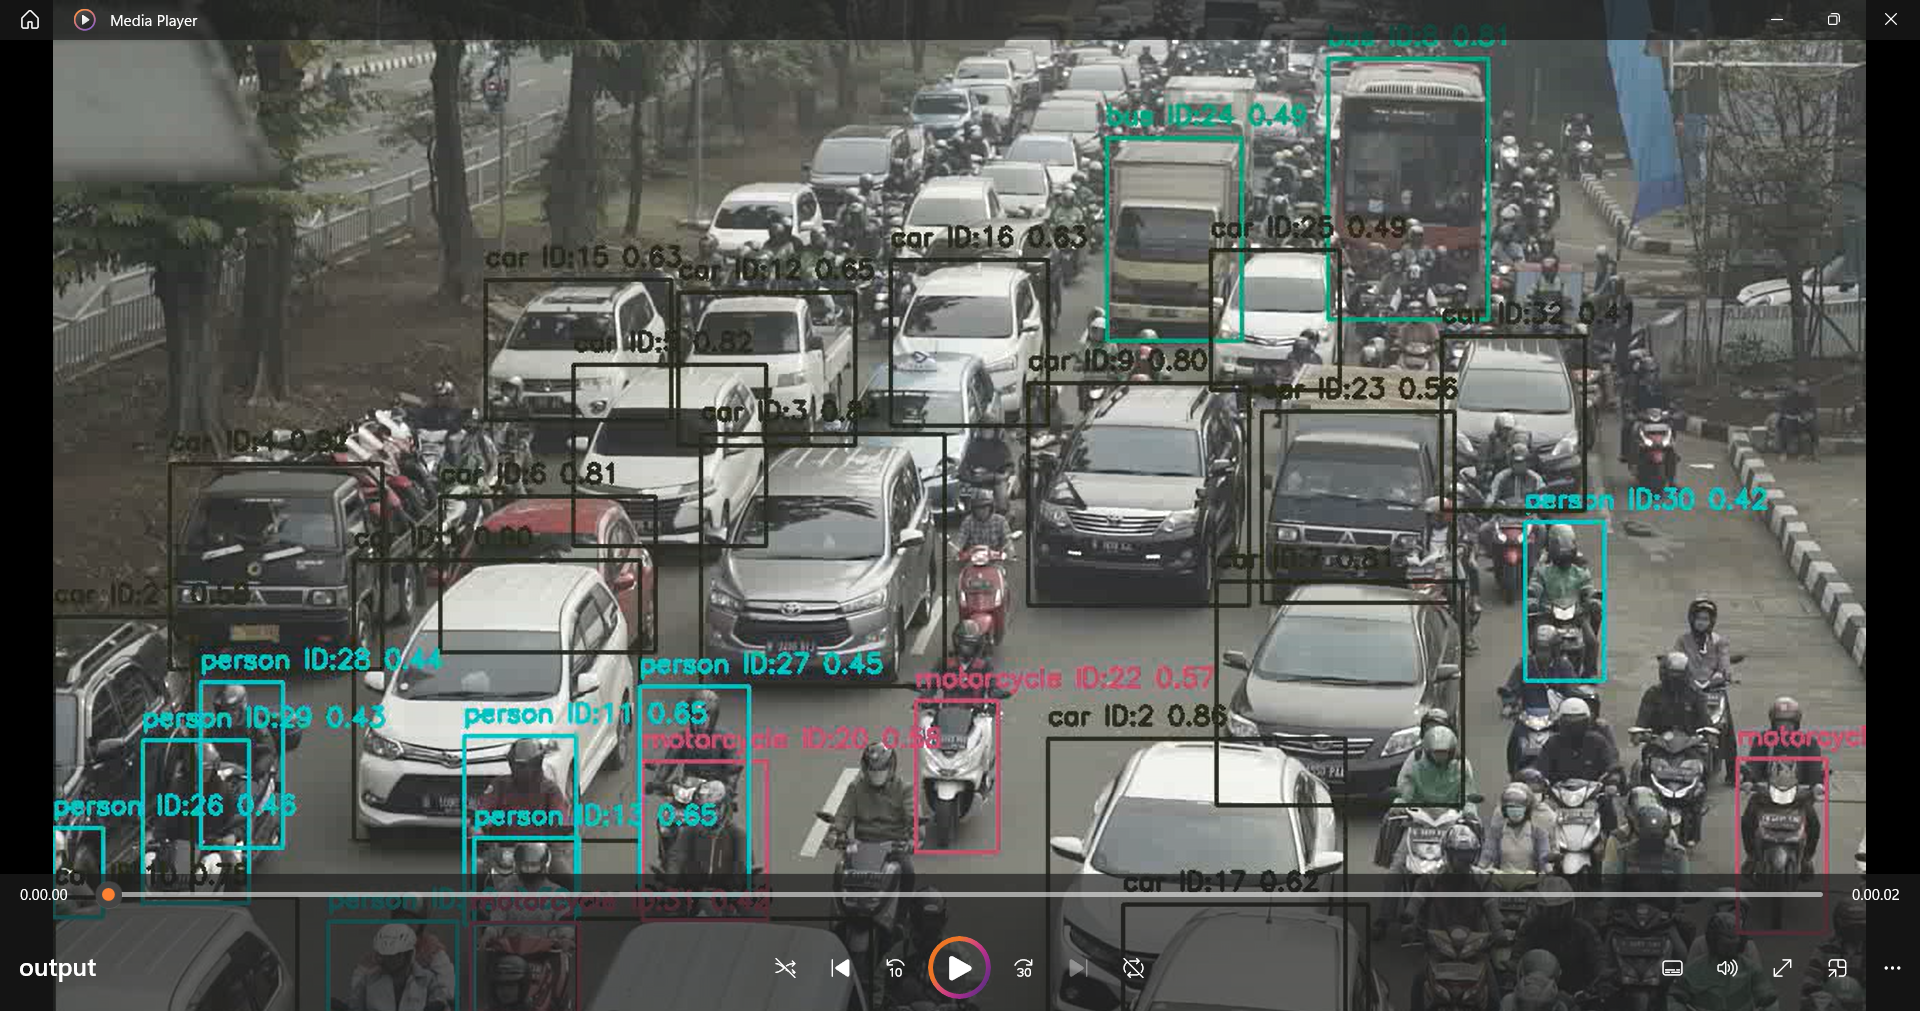

In [12]:
from IPython.display import display
from PIL import Image

img_path = r"C:\Users\91950\Downloads\yolo-video-op.png"

img = Image.open(img_path)
display(img)